Tarea 2 Data Analisys & Machine Learning \
Eduardo Mathias Ruiz Quezada \
2022443162 \
edruiz2022@udec.cl 

##### PREGUNTA 1
**R**: En primer lugar, se realizó una limpieza de la base de datos eliminando las variables edu2 y edu3 debido a su alta proporción de datos faltantes (aproximadamente el 45% de la muestra), previniendo así la pérdida masiva de observaciones en las estimaciones posteriores. Adicionalmente, se transformó la variable date a formato datetime para habilitar el tratamiento temporal del panel.
El análisis de las estadísticas descriptivas revela comportamientos esperables dados los efectos de la pandemia: la movilidad laboral (workplaces) presenta una distribución aproximadamente normal pero con una media negativa (-18.6%) y marcados outliers en su límite inferior (hasta -76.7%), reflejando las semanas de confinamiento extremo. En contraste, el índice de restricciones (Valor_Stringency_Index) exhibe una distribución bimodal que ilustra periodos de nula intervención versus etapas de alta restricción. Finalmente, la variable de contagios (daily_cases) muestra un fuerte sesgo positivo típico en datos epidemiológicos, donde la media (2,355) es significativamente mayor que la mediana (632) debido a los valores atípicos extremos generados durante los picos de contagios.

##### PREGUNTA 2
**R**: Se estimó un modelo Pooled OLS para evaluar el impacto de las restricciones gubernamentales (Valor_Stringency_Index) sobre la movilidad laboral (workplaces), para evitar sesgos por variable omitida, se probaron múltiples especificaciones, determinando mediante criterios de información (menor AIC y BIC) y un mayor $R^2$ Ajustado que la inclusión de controles estructurales como la población, desempleo, contagios y el peso del sector industrial (industry) mejoraban el ajuste global. 
Excluyendo old_age_dependency por falta de significancia estadística ($p>0.05$), el modelo final demuestra que el índice de restricciones tiene un efecto negativo y altamente significativo: un aumento de un punto en el índice de severidad reduce la movilidad laboral en aproximadamente 0.20 puntos porcentuales. Se observa además que una mayor dependencia del sector industrial aumenta la movilidad presencial ($p=0.021$), consistente con la menor factibilidad de teletrabajo en dicho sector.
Sin embargo, coeficientes contraintuitivos en variables como contagios y desempleo (los cuales resultaron positivos y significativos), sumado a indicios de multicolinealidad, sugieren que el modelo Pooled OLS sufre de sesgo por heterogeneidad no observada al no capturar las características invariantes de cada ciudad, limitando su validez causal.

##### PREGUNTA 3
**R**:Se estimó un modelo de Efectos Fijos (FE) a nivel de ciudad para controlar por la heterogeneidad no observada e invariante en el tiempo que sesgaba el modelo OLS anterior. Debido a la colinealidad perfecta que impone este modelo sobre las variables estáticas, se excluyeron los controles estructurales (como población e industria), limitando la ecuación a variables dinámicas.
Al interpretar el significado y ajuste de este modelo, destacan los siguientes hallazgos:
1. Impacto de las restricciones (Valor_Stringency_Index): Los resultados demuestran que las restricciones gubernamentales tienen un impacto negativo mucho más fuerte que el estimado por OLS. Un aumento de un punto en el índice de severidad reduce la movilidad laboral en -0.398 puntos porcentuales ($t=-22.33$), revelando que el OLS estaba subestimando el impacto real al no limpiar las características fijas de cada urbe.
2. Apoyo económico (Valor_EconomicSupportindex): Resulta interesante notar que el apoyo económico mostró un efecto positivo (0.052) y estadísticamente significativo ($t=3.29>1.96$), lo que podría sugerir que los subsidios a empresas mantuvieron la vinculación laboral de los empleados permitiéndoles mantener sus contratos activos, en lugar de ser despedidos masivamente.
A pesar de estas mejoras, la persistencia de coeficientes positivos contraintuitivos para los contagios diarios y el desempleo indica que controlar únicamente por la entidad (ciudad) es insuficiente para capturar las dinámicas temporales propias de la evolución de la pandemia, como el cansancio frente a los encierros a medida que avanzaban los meses.

##### PREGUNTA 4
**R**: Se estimó un modelo de Efectos Aleatorios (RE) para evaluar el impacto de las políticas gubernamentales, permitiendo la reincorporación de variables estructurales invariantes en el tiempo que fueron omitidas en la especificación de Efectos Fijos.
Los resultados indican que el índice de severidad de las restricciones (Valor_Stringency_Index) mantiene un impacto negativo, fuerte y altamente significativo, reduciendo la movilidad laboral en -0.382 puntos porcentuales por cada punto adicional del índice ($t=-51.34$). El apoyo económico gubernamental sigue mostrando un efecto positivo significativo (0.056, $t=9.68$).
Respecto a las variables estáticas, se descubrió que la población de la ciudad tiene un efecto negativo y significativo sobre la movilidad, sugiriendo una mayor capacidad de adaptación al teletrabajo en urbes grandes. Por el contrario, la proporción del sector industrial (industry), que resultaba significativa bajo OLS, pierde su significancia estadística a un nivel del 95% de confianza ($t=1.86<1.96$), demostrando que su impacto previo estaba confundido con la varianza no observada del panel.

##### PREGUNTA 5
**R**: Al analizar en conjunto las estimaciones de los modelos Pooled OLS (Pregunta 2), Efectos Fijos (Pregunta 3) y Efectos Aleatorios (Pregunta 4), se concluye lo siguiente respecto al impacto de las políticas gubernamentales:
1. Diferencias entre los resultados y su justificación: Los resultados obtenidos a través de las tres especificaciones muestran una evolución clara en la precisión de la estimación. El modelo Pooled OLS inicial presentó un sesgo evidente, arrojando coeficientes contraintuitivos, resultado de ignorar la heterogeneidad no observada entre ciudades (sesgo por variable omitida). Al transitar hacia Efectos Fijos (FE) y Efectos Aleatorios (RE), los coeficientes del Valor_Stringency_Index se estabilizaron en torno a -0.39, demostrando que el OLS subestimaba a la mitad el impacto real de las restricciones.
2. Modelo más adecuado: En mi opinión, el modelo más adecuado para responder a la pregunta de investigación es el de Efectos Fijos (FE). A diferencia de RE, el modelo FE permite que las características inobservables de las ciudades (cultura, infraestructura, resiliencia) estén correlacionadas con las políticas gubernamentales, lo cual es el supuesto más realista en un contexto de crisis sanitaria. El supuesto de RE de que dichas características no están correlacionadas con el error es poco probable en datos de comportamiento social.
3. Variables robustas a la especificación: Finalmente, las variables que resultaron ser consistentemente robustas fueron el Valor_Stringency_Index y el Valor_EconomicSupportIndex. Ambas mantuvieron consistentemente su signo y alta significancia estadística a través de los distintos modelos, confirmando que la respuesta gubernamental fue el factor determinante, tanto restrictivo como mitigador, de la movilidad laboral durante la pandemia.

##### PREGUNTA 6
**R**: Se estimó un modelo de Efectos Aleatorios Correlacionados (CRE), también conocido como enfoque de Mundlak, con el objetivo de superar el supuesto restrictivo del modelo RE clásico y permitir la estimación consistente de variables estáticas. Para ello, se incorporaron las medias grupales (por ciudad) de las variables dinámicas al modelo de Efectos Aleatorios.
Los resultados confirman empíricamente la pertinencia de este enfoque. La variable correspondiente a la media temporal de las restricciones (Valor_Stringency_Index_mean) resultó ser altamente significativa ($p=0.0003$). Este hallazgo es fundamental, ya que es la prueba formal de que los efectos no observados de cada ciudad sí se encuentran correlacionados con el nivel de restricciones impuestas. Consecuentemente, se demuestra que el modelo RE clásico (Pregunta 4) sufría de sesgo. Al corregir dicha endogeneidad, el modelo CRE arroja un estimador insesgado y consistente, reafirmando que un aumento de un punto en el índice de severidad reduce la movilidad laboral en -0.398 puntos porcentuales.

##### PREGUNTA 7
**R**: 
1. Modelo Preferido: De acuerdo con la evidencia empírica obtenida, el modelo categóricamente preferido es el de Efectos Aleatorios Correlacionados (CRE), o equivalentemente para las variables dinámicas, el de Efectos Fijos (FE). La justificación radica en el rechazo estadístico de las especificaciones alternativas. Por un lado, la prueba de agrupabilidad (F-test for Poolability = 35.30, $p=0.000$) rechaza la hipótesis nula de un intercepto común, invalidando el uso de Pooled OLS debido a la presencia de heterogeneidad no observada. Por otro lado, la significancia estadística de los términos de Mundlak en el modelo CRE ($p=0.0003$) rechaza el supuesto de exogeneidad de los efectos individuales del modelo RE clásico. Por ende, FE y CRE son las únicas aproximaciones que otorgan estimadores consistentes para este panel.

2. Inferencia General: Basándose en los modelos robustos, se infiere que las políticas y restricciones gubernamentales ejercen un efecto causal, negativo y altamente significativo sobre la movilidad laboral. Controlando por el avance intrínseco de la pandemia (casos diarios) y el ciclo económico (desempleo y apoyos fiscales), el efecto de las políticas de contención se mantiene constante en una reducción aproximada de -0.40 puntos porcentuales en la movilidad por cada punto adicional de rigurosidad impuesta. En conclusión, el intervencionismo estatal fue un mecanismo efectivo y directo para reducir el desplazamiento de la población hacia sus lugares de trabajo.

##### PREGUNTA 8
**R**: Para estimar el efecto causal puro de las restricciones y sortear posibles problemas de endogeneidad temporal, se implementó la metodología de Control Sintético. Se seleccionó como unidad tratada a la ciudad de Barcelona, identificando la semana 46 como el periodo de tratamiento ($T_0$) debido al incremento abrupto en su índice de rigurosidad (de 71.3 a 77.2). Para la construcción del contrafactual, el donor pool se restringió exclusivamente a ciudades fuera de España, previniendo así la contaminación de la muestra por shocks de políticas de confinamiento a nivel nacional. Utilizando predictores estructurales promediados pre-tratamiento (población, industria, desempleo y casos diarios), el algoritmo asignó mayores ponderaciones a ciudades como París, Niza y Berlín.

Al analizar los resultados gráficos, el periodo pre-tratamiento (semanas 10 a 45) exhibe fluctuaciones considerables en el Gaps Plot, sugiriendo que la combinación lineal de las ciudades europeas donantes no logró replicar con exactitud la trayectoria basal de Barcelona. Sin embargo, el hallazgo más relevante ocurre en el periodo post-tratamiento: contrario a la hipótesis inicial, la brecha se torna fuertemente positiva (alcanzando diferencias de hasta +13 puntos).

Esta divergencia implica que la movilidad observada en Barcelona fue significativamente mayor a la de su contrafactual sintético tras la semana 46. Lejos de invalidar el método, este resultado evidencia la vulnerabilidad de las ciudades donantes frente a shocks exógenos simultáneos. Es altamente probable que en esa ventana temporal exacta, coincidente con la segunda gran ola invernal en Europa continental, naciones como Francia y Alemania hayan decretado confinamientos (lockdowns) considerablemente más estrictos que los aplicados en Cataluña. Consecuentemente, la movilidad del clon sintético se desplomó, dejando a la Barcelona real con una movilidad comparativamente superior y demostrando la alta sensibilidad de esta metodología a la selección de controles internacionales durante una crisis global sincronizada.

#### PREGUNTA 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
#Cargar la base de datos

df = pd.read_csv('dataset_prueba.csv')

#Identificar estructura y tipos de datos
print("--- Información general de la base de datos ---")
df.info()

# Visualizar las primeras filas
display(df.head())

#Estadísticas descriptivas de las variables numéricas
print("\n--- Estadísticas descriptivas ---")
display(df.describe())

#Revisión inicial de datos faltantes
print("\n--- Conteo de datos faltantes por variable ---")
display(df.isnull().sum())

--- Información general de la base de datos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12040 entries, 0 to 12039
Data columns (total 41 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   iso_code                                            12040 non-null  object 
 1   date                                                12040 non-null  object 
 2   retail_and_recreation_percent_change_from_baseline  12040 non-null  float64
 3   grocery_and_pharmacy_percent_change_from_baseline   12040 non-null  float64
 4   parks_percent_change_from_baseline                  12040 non-null  float64
 5   transit_stations_percent_change_from_baseline       12040 non-null  float64
 6   workplaces_raw                                      12040 non-null  float64
 7   residential_percent_change_from_baseline            12040 non-null  float64
 8   trend                       

,iso_code,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_raw,residential_percent_change_from_baseline,trend,workplaces,...,edu3,age_dependency,old_age_dependency,young_age_dependency,sex_ratio,unemp,f_unemp,m_unemp,foreigners,country
0,DE-BE,2020-02-17,6.0,3.0,15.0,4.0,1.0,0.0,9.266668,4.244073,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
1,DE-BE,2020-02-24,1.6,0.0,8.6,0.0,0.2,0.6,5.006175,2.468286,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
2,DE-BE,2020-03-02,2.6,6.4,8.2,-0.4,0.4,1.0,-3.765428,-2.845394,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
3,DE-BE,2020-03-09,-3.4,3.4,-1.0,-5.8,-0.6,1.8,-12.537031,-11.510297,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
4,DE-BE,2020-03-16,-11.8,11.4,-4.6,-16.0,-7.8,4.6,-21.308634,-21.800890,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE



--- Estadísticas descriptivas ---


,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_raw,residential_percent_change_from_baseline,trend,workplaces,Valor_Stringency_Index,Valor_GovernmentResponseIndex,...,edu2,edu3,age_dependency,old_age_dependency,young_age_dependency,sex_ratio,unemp,f_unemp,m_unemp,foreigners
count,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,...,6580.000000,6580.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000
mean,-16.437272,5.124340,49.675619,-17.602313,-25.002928,7.071179,-19.004247,-18.667353,27.486254,30.636789,...,0.424197,0.479946,0.653934,0.320896,0.334465,106.714479,12.220515,0.113865,0.121292,8.145515
std,21.599436,15.707311,71.697845,24.540594,14.681099,6.022794,9.857500,11.801356,29.835937,30.244900,...,0.120555,0.127955,0.072849,0.052749,0.062533,4.247242,8.265315,0.070448,0.093873,2.991933
min,-95.600000,-66.200000,-95.800000,-88.600000,-87.000000,-3.800000,-80.071581,-76.787132,0.000000,0.000000,...,0.249605,0.180376,0.520499,0.255039,0.238051,91.448785,3.000000,0.035794,0.024618,2.000000
25%,-26.400000,-3.200000,4.800000,-31.800000,-32.400000,3.200000,-22.614732,-24.358379,0.000000,0.000000,...,0.298762,0.374819,0.609178,0.280293,0.282108,103.522992,6.000000,0.061770,0.052677,6.000000
50%,-11.400000,6.200000,34.200000,-18.400000,-22.800000,5.600000,-17.430940,-16.819961,15.858000,32.030000,...,0.431917,0.513402,0.650998,0.306745,0.331407,107.013220,8.000000,0.085044,0.078852,9.000000
75%,-3.600000,15.000000,78.800000,-4.400000,-14.400000,9.400000,-13.324697,-10.883994,53.420000,60.160000,...,0.520089,0.573491,0.681714,0.338193,0.366313,109.531509,18.000000,0.149918,0.163352,11.000000
max,74.600000,83.600000,631.000000,123.200000,6.600000,42.600000,12.355647,19.057630,93.520000,81.306000,...,0.689973,0.678689,0.837478,0.485328,0.507336,115.752855,36.000000,0.328653,0.427472,15.000000



--- Conteo de datos faltantes por variable ---


iso_code                                                 0
date                                                     0
retail_and_recreation_percent_change_from_baseline       0
grocery_and_pharmacy_percent_change_from_baseline        0
parks_percent_change_from_baseline                       0
transit_stations_percent_change_from_baseline            0
workplaces_raw                                           0
residential_percent_change_from_baseline                 0
trend                                                    0
workplaces                                               0
Valor_Stringency_Index                                   0
Valor_GovernmentResponseIndex                            0
Valor_EconomicSupportIndex                               0
Valor_Containment_Health_index                           0
workplace_closing                                        0
daily_cases                                              0
d2                                                      

In [2]:
#Eliminar variables con demasiados nulos que no están en el diccionario
df_clean = df.drop(columns=['edu2', 'edu3'])

#Convertir la variable 'date' a formato datetime
df_clean['date'] = pd.to_datetime(df_clean['date'])

#Verificar que los cambios funcionaron
print("--- Información actualizada ---")
df_clean.info()

print("\n--- Nulos restantes ---")
print(df_clean.isnull().sum().max())

--- Información actualizada ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12040 entries, 0 to 12039
Data columns (total 39 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   iso_code                                            12040 non-null  object        
 1   date                                                12040 non-null  datetime64[ns]
 2   retail_and_recreation_percent_change_from_baseline  12040 non-null  float64       
 3   grocery_and_pharmacy_percent_change_from_baseline   12040 non-null  float64       
 4   parks_percent_change_from_baseline                  12040 non-null  float64       
 5   transit_stations_percent_change_from_baseline       12040 non-null  float64       
 6   workplaces_raw                                      12040 non-null  float64       
 7   residential_percent_change_from_baseline            12040 non-

--- Estadísticas Descriptivas de Variables Clave ---


,workplaces,Valor_Stringency_Index,workplace_closing,daily_cases,unemp
count,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000
mean,-18.667353,27.486254,0.850831,2355.733422,12.220515
std,11.801356,29.835937,0.997067,3154.914356,8.265315
min,-76.787132,0.000000,0.000000,0.000000,3.000000
25%,-24.358379,0.000000,0.000000,0.037200,6.000000
50%,-16.819961,15.858000,0.000000,632.010400,8.000000
75%,-10.883994,53.420000,2.000000,3815.644400,18.000000
max,19.057630,93.520000,3.000000,22203.314200,36.000000


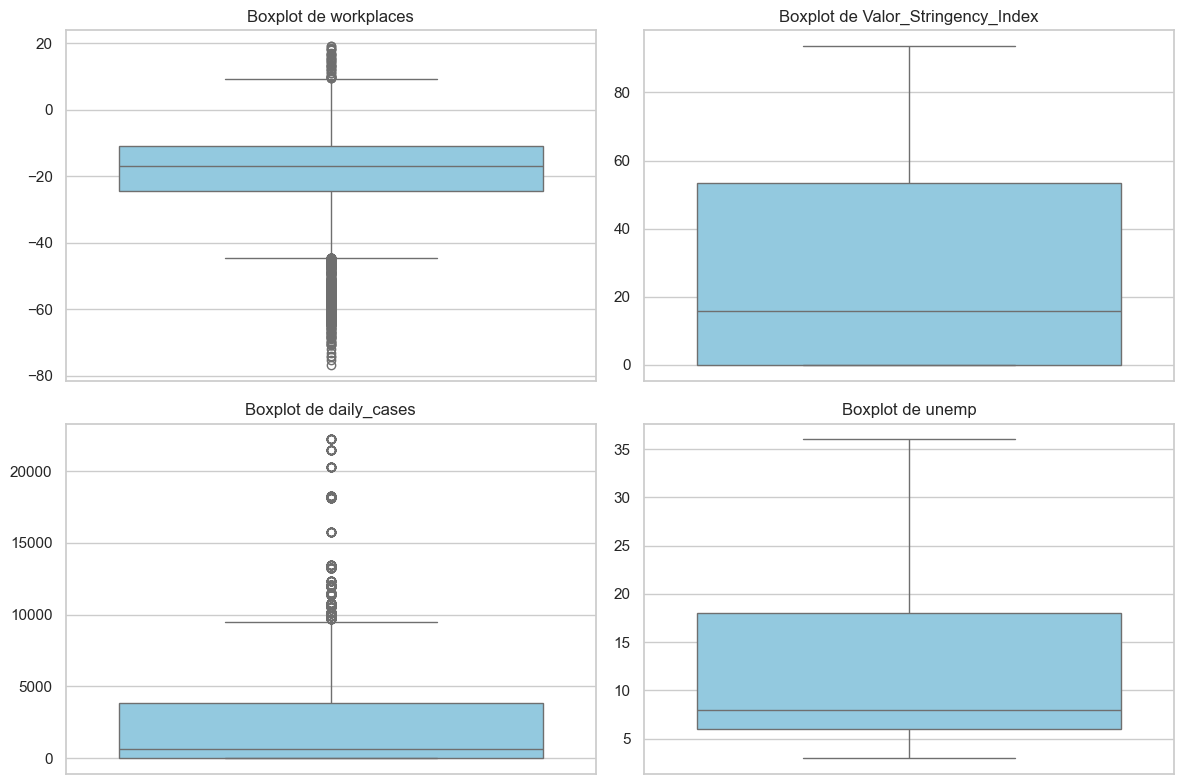

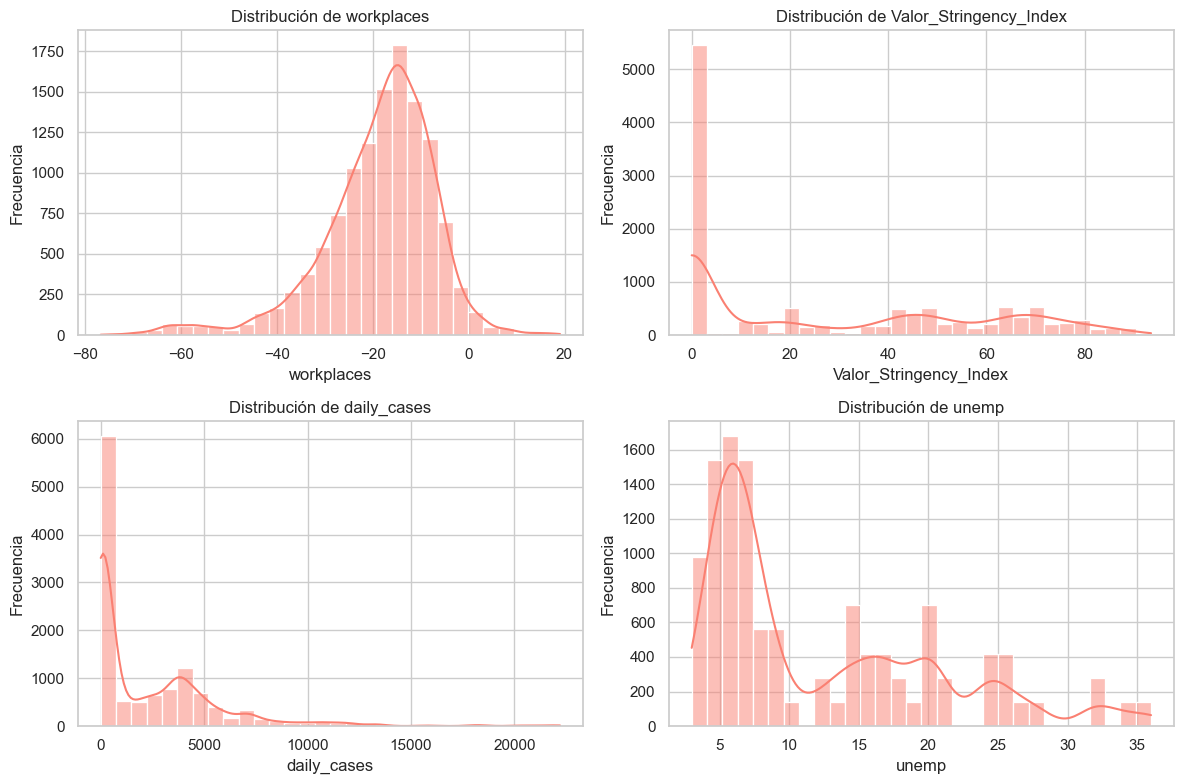

In [ ]:
#Definir las variables más relevantes para nuestro estudio
variables_clave = ['workplaces', 'Valor_Stringency_Index', 'workplace_closing', 'daily_cases', 'unemp']

#Estadísticas descriptivas detalladas
print("--- Estadísticas Descriptivas de Variables Clave ---")
display(df_clean[variables_clave].describe())

#Gráficos de caja para identificar Outliers
plt.figure(figsize=(12, 8))
for i, var in enumerate(['workplaces', 'Valor_Stringency_Index', 'daily_cases', 'unemp'], 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df_clean[var], color='skyblue')
    plt.title(f'Boxplot de {var}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

#Histogramas para ver la distribución
plt.figure(figsize=(12, 8))
for i, var in enumerate(['workplaces', 'Valor_Stringency_Index', 'daily_cases', 'unemp'], 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_clean[var], kde=True, bins=30, color='salmon')
    plt.title(f'Distribución de {var}')
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

#### PREGUNTA 2

In [ ]:
import statsmodels.formula.api as smf
import pandas as pd

# --- MODELO 1: LÍNEA BASE ---
formula_1 = 'workplaces ~ Valor_Stringency_Index + daily_cases + unemp'
modelo_1 = smf.ols(formula=formula_1, data=df_clean).fit()

# --- MODELO 2: EXPANDIDO ---
# Agregamos población, adultos mayores y sector industrial
formula_2 = 'workplaces ~ Valor_Stringency_Index + daily_cases + unemp + Population + old_age_dependency + industry'
modelo_2 = smf.ols(formula=formula_2, data=df_clean).fit()

# --- COMPARACIÓN DE MÉTRICAS CLAVE ---
print("=== COMPARACIÓN DE MODELOS POOLED OLS ===")
comparacion = pd.DataFrame({
    'Métrica': ['R-cuadrado Ajustado', 'AIC', 'BIC'],
    'Modelo 1 (Base)': [modelo_1.rsquared_adj, modelo_1.aic, modelo_1.bic],
    'Modelo 2 (Expandido)': [modelo_2.rsquared_adj, modelo_2.aic, modelo_2.bic]
})
display(comparacion)

print("\n\n=== RESUMEN MODELO 2 (EXPANDIDO) ===")
#Imprimir el resumen del Modelo 2 para ver los P-value de las nuevas variables
print(modelo_2.summary())

=== COMPARACIÓN DE MODELOS POOLED OLS ===


,Métrica,Modelo 1 (Base),Modelo 2 (Expandido)
0,R-cuadrado Ajustado,0.205453,0.229532
1,AIC,90837.652754,90470.130652
2,BIC,90867.236713,90521.902580




=== RESUMEN MODELO 2 (EXPANDIDO) ===
                            OLS Regression Results                            
Dep. Variable:             workplaces   R-squared:                       0.230
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     598.8
Date:                Mon, 25 May 2026   Prob (F-statistic):               0.00
Time:                        18:41:03   Log-Likelihood:                -45228.
No. Observations:               12040   AIC:                         9.047e+04
Df Residuals:                   12033   BIC:                         9.052e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

#### PREGUNTA 3

In [ ]:
from linearmodels.panel import PanelOLS, compare

#Preparar los datos como un Panel

df_panel = df_clean.set_index(['CODE', 'date'])

#Definir las fórmulas
#Modelo 1: Efectos Fijos Base (Variables dinámicas clave)
formula_fe_1 = 'workplaces ~ 1 + Valor_Stringency_Index + daily_cases + unemp + EntityEffects'

#Modelo 2: Efectos Fijos con Apoyo Económico
formula_fe_2 = 'workplaces ~ 1 + Valor_Stringency_Index + daily_cases + unemp + Valor_EconomicSupportIndex + EntityEffects'

#Estimar ambos modelos
#cov_type='clustered' ajusta los errores para reconocer que los datos de una misma ciudad están correlacionados entre sí
modelo_fe_1 = PanelOLS.from_formula(formula_fe_1, data=df_panel).fit(cov_type='clustered', cluster_entity=True)
modelo_fe_2 = PanelOLS.from_formula(formula_fe_2, data=df_panel).fit(cov_type='clustered', cluster_entity=True)

#Comparar los resultados
print("=== COMPARACIÓN DE MODELOS DE EFECTOS FIJOS ===")
#Comparar ambos modelos
resumen_comparativo = compare({'FE Base': modelo_fe_1, 'FE Apoyo Econ.': modelo_fe_2})
print(resumen_comparativo)

=== COMPARACIÓN DE MODELOS DE EFECTOS FIJOS ===
                      Model Comparison                      
                                      FE Base FE Apoyo Econ.
------------------------------------------------------------
Dep. Variable                      workplaces     workplaces
Estimator                            PanelOLS       PanelOLS
No. Observations                        12040          12040
Cov. Est.                           Clustered      Clustered
R-squared                              0.2673         0.2723
R-Squared (Within)                     0.2673         0.2723
R-Squared (Between)                   -0.7772        -0.7135
R-Squared (Overall)                    0.1199         0.1332
F-statistic                            1453.6         1117.8
P-value (F-stat)                       0.0000         0.0000
============================     ============   ============
Intercept                             -17.829        -17.979
                                    (

#### PREGUNTA 4

In [ ]:
from linearmodels.panel import RandomEffects, compare

#Definir las fórmulas
#Modelo 1: RE Base (Solo variables dinámicas)
formula_re_1 = 'workplaces ~ 1 + Valor_Stringency_Index + daily_cases + unemp'

#Modelo 2: RE Expandido (Dinámicas + Estáticas + Apoyo Económico)
formula_re_2 = 'workplaces ~ 1 + Valor_Stringency_Index + daily_cases + unemp + Valor_EconomicSupportIndex + industry + Population'

#Especificar y ajustar ambos modelos
modelo_re_1 = RandomEffects.from_formula(formula_re_1, data=df_panel).fit()
modelo_re_2 = RandomEffects.from_formula(formula_re_2, data=df_panel).fit()

#Comparar los resultados
print("=== COMPARACIÓN DE MODELOS DE EFECTOS ALEATORIOS ===")
resumen_re_comparativo = compare({'RE Base': modelo_re_1, 'RE Expandido': modelo_re_2})
print(resumen_re_comparativo)

=== COMPARACIÓN DE MODELOS DE EFECTOS ALEATORIOS ===
                      Model Comparison                      
                                     RE Base    RE Expandido
------------------------------------------------------------
Dep. Variable                     workplaces      workplaces
Estimator                      RandomEffects   RandomEffects
No. Observations                       12040           12040
Cov. Est.                         Unadjusted      Unadjusted
R-squared                             0.2606          0.2643
R-Squared (Within)                    0.2670          0.2714
R-Squared (Between)                  -0.6519         -0.4041
R-Squared (Overall)                   0.1373          0.1761
F-statistic                           1413.9          720.30
P-value (F-stat)                      0.0000          0.0000
============================ =============== ===============
Intercept                            -16.977         -17.833
                                

#### PREGUNTA 5

#### PREGUNTA 6

In [ ]:
#Creamos las medias por ciudad (Mundlak terms)
df_cre = df_clean.copy()
variables_dinamicas = ['Valor_Stringency_Index', 'daily_cases', 'unemp', 'Valor_EconomicSupportIndex']

for var in variables_dinamicas:
    df_cre[f'{var}_mean'] = df_cre.groupby('CODE')[var].transform('mean')

#Definir la fórmula CRE
#Incluir las variables originales Y los promedios (que capturan el efecto fijo)
formula_cre = 'workplaces ~ 1 + Valor_Stringency_Index + daily_cases + unemp + Valor_EconomicSupportIndex + industry + Population + Valor_Stringency_Index_mean + daily_cases_mean + unemp_mean + Valor_EconomicSupportIndex_mean'

#Estimar como un modelo de Efectos Aleatorios
from linearmodels.panel import RandomEffects
modelo_cre = RandomEffects.from_formula(formula_cre, data=df_cre.set_index(['CODE', 'date'])).fit()

print("=== RESULTADOS MODELO CRE (MUNDLAK) ===")
print(modelo_cre.summary)

=== RESULTADOS MODELO CRE (MUNDLAK) ===
                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.2752
Estimator:              RandomEffects   R-squared (Between):              0.5527
No. Observations:               12040   R-squared (Within):               0.2723
Date:                Mon, May 25 2026   R-squared (Overall):              0.3119
Time:                        18:41:04   Log-likelihood                -4.401e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      456.63
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                F(10,12029)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):        

#### PREGUNTA 7

### PREGUNTA 8


In [ ]:
from pysyncon import Dataprep, PenalizedSynth
import warnings
warnings.filterwarnings('ignore')

#Identificar controles: Todas las ciudades que NO son de España
ciudades_control = df_clean[df_clean['country'] != 'ES']['NAME'].unique().tolist()

dataprep = Dataprep(
    foo=df_clean,
    predictors=[
        "Population",
        "industry",
        "unemp",
    ],
    predictors_op="mean",
    time_predictors_prior=range(10, 46), #Periodo pre-tratamiento
    special_predictors=[
        ("daily_cases", range(10, 46), "mean"),
    ],
    dependent="workplaces",
    unit_variable="NAME",
    time_variable="week",
    treatment_identifier="Barcelona",
    controls_identifier=ciudades_control,
    time_optimize_ssr=range(10, 46),
)


Pesos del Control Sintético (ciudades donantes):
Berlin         0.189
Nice           0.343
Montpellier    0.195
Paris          0.272
Name: weights, dtype: float64


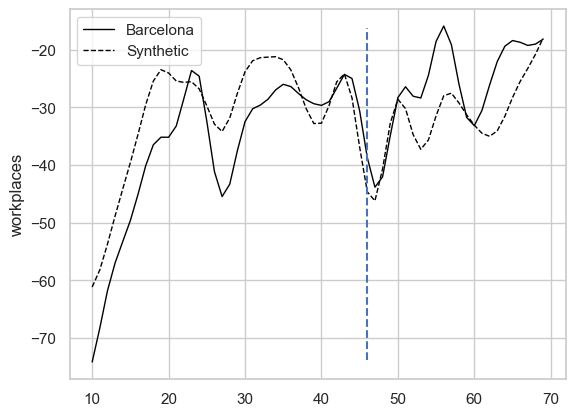

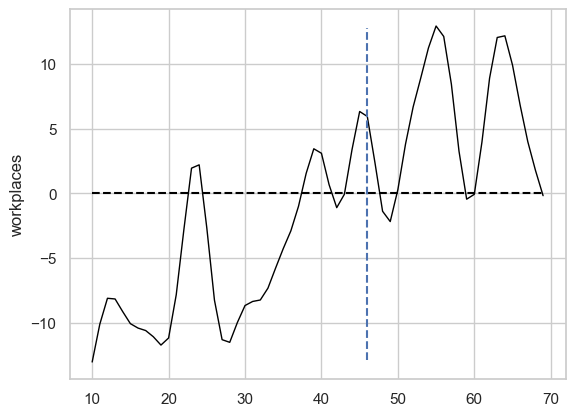

In [ ]:
# Utilizar PenalizedSynth como estimador de control sintético
pen = PenalizedSynth()
pen.fit(dataprep, lambda_=0.01)

#Ver los pesos asignados a cada ciudad de control para armar el "clon sintético"
print("Pesos del Control Sintético (ciudades donantes):")
print(pen.weights()[pen.weights() > 0]) #Solo mostrar las que tuvieron un peso > 0

#Graficar el impacto (Path plot = ambas líneas; Gaps plot = diferencia neta)
pen.path_plot(time_period=range(10, 70), treatment_time=46)
pen.gaps_plot(time_period=range(10, 70), treatment_time=46)
